# Sprint 1 — Exploratory Data Analysis (EDA)
## Corporación Favorita Grocery Sales Forecasting

**Goal:** Understand the dataset structure, clean the data, identify patterns and key statistical properties before modeling.

---

### Dataset
- **Source:** Kaggle — Corporación Favorita Grocery Sales Forecasting
- **Period:** January 2013 – August 2017
- **Target:** Store 44, Item 1047679 (highest volume item in top store)

---



# Sprint 1 — Exploratory Data Analysis (EDA)
## Corporación Favorita Grocery Sales Forecasting

**Author:** Armin
**Dataset:** [Kaggle — Corporación Favorita](https://www.kaggle.com/competitions/favorita-grocery-sales-forecasting )
**Period:** January 2013 – August 2017

---

### Project Overview
This notebook covers Sprint 1 of the time series forecasting project. The goal is to load, clean,
and explore the Corporación Favorita dataset — a large-scale retail sales dataset from Ecuador
with over 125 million records across 54 stores and 4,000+ products.

The analysis focuses on identifying temporal patterns, seasonal effects, external economic factors,
and data quality issues before proceeding to model development in Sprint 2.

---



In [2]:
import pandas as pd

# Učitavanje podataka direktno iz podfoldara
df_train = pd.read_csv('train.csv/train.csv')
df_stores = pd.read_csv('stores.csv/stores.csv')
df_items = pd.read_csv('items.csv/items.csv')
df_transactions = pd.read_csv('transactions.csv/transactions.csv')
df_oil = pd.read_csv('oil.csv/oil.csv')
df_holidays = pd.read_csv('holidays_events.csv/holidays_events.csv')

print("Train shape:", df_train.shape)
print("Stores shape:", df_stores.shape)
print("Items shape:", df_items.shape)
print("Transactions shape:", df_transactions.shape)
print("Oil shape:", df_oil.shape)
print("Holidays shape:", df_holidays.shape)


C:\Users\armin\AppData\Local\Temp\ipykernel_1688\2751170776.py:4: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('train.csv/train.csv')


Train shape: (125497040, 6)
Stores shape: (54, 5)
Items shape: (4100, 4)
Transactions shape: (83488, 3)
Oil shape: (1218, 2)
Holidays shape: (350, 6)


## 2. Data Cleaning

Before analysis, the following cleaning steps are applied:

- **`onpromotion`**: Missing values filled with `False` (no promotion assumed)
- **Oil prices**: 43 missing values filled using forward fill (`ffill`) then backward fill (`bfill`) —
  gaps occur on weekends and holidays when markets are closed
- **Date columns**: Converted from string to `datetime` format for time-based operations
- **Negative sales**: Removed ~7,800 records with negative `unit_sales` (represent product returns,
  not relevant for demand forecasting)


In [3]:
# Pogledamo prvih 5 redova i osnovne info za train
print("=== TRAIN - prvih 5 redova ===")
print(df_train.head())

print("\n=== TRAIN - info o kolonama ===")
print(df_train.dtypes)

print("\n=== TRAIN - nedostajuće vrijednosti ===")
print(df_train.isnull().sum())


=== TRAIN - prvih 5 redova ===
   id        date  store_nbr  item_nbr  unit_sales onpromotion
0   0  2013-01-01         25    103665         7.0         NaN
1   1  2013-01-01         25    105574         1.0         NaN
2   2  2013-01-01         25    105575         2.0         NaN
3   3  2013-01-01         25    108079         1.0         NaN
4   4  2013-01-01         25    108701         1.0         NaN

=== TRAIN - info o kolonama ===
id               int64
date            object
store_nbr        int64
item_nbr         int64
unit_sales     float64
onpromotion     object
dtype: object

=== TRAIN - nedostajuće vrijednosti ===
id                    0
date                  0
store_nbr             0
item_nbr              0
unit_sales            0
onpromotion    21657651
dtype: int64


In [5]:
# Inspect other datasets
print("=== STORES ===")
print(df_stores.head())

print("\n=== ITEMS ===")
print(df_items.head())

print("\n=== OIL ===")
print(df_oil.head())
print("Oil - missing values:", df_oil.isnull().sum().to_dict())

print("\n=== HOLIDAYS ===")
print(df_holidays.head())


=== STORES ===
   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4

=== ITEMS ===
   item_nbr        family  class  perishable
0     96995     GROCERY I   1093           0
1     99197     GROCERY I   1067           0
2    103501      CLEANING   3008           0
3    103520     GROCERY I   1028           0
4    103665  BREAD/BAKERY   2712           1

=== OIL ===
         date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97
3  2013-01-04       93.12
4  2013-01-07       93.20
Oil - missing values: {'date': 0, 'dcoilwtico': 43}

=== HOLIDAYS ===
         date    

In [6]:
import numpy as np

# 1. Fix onpromotion column in train (fill NaN with False)
df_train['onpromotion'] = df_train['onpromotion'].fillna(False)

# 2. Fix oil prices (fill missing values with forward fill, then backward fill)
df_oil['dcoilwtico'] = df_oil['dcoilwtico'].ffill().bfill()

# 3. Convert date columns to datetime format
df_train['date'] = pd.to_datetime(df_train['date'])
df_oil['date'] = pd.to_datetime(df_oil['date'])
df_holidays['date'] = pd.to_datetime(df_holidays['date'])
df_transactions['date'] = pd.to_datetime(df_transactions['date'])

# 4. Remove negative unit_sales (returns/refunds - not relevant for forecasting)
df_train = df_train[df_train['unit_sales'] >= 0]

# Verify cleaning
print("Missing values after cleaning:")
print("train - onpromotion:", df_train['onpromotion'].isnull().sum())
print("oil - dcoilwtico:", df_oil['dcoilwtico'].isnull().sum())
print("Negative sales removed. New train shape:", df_train.shape)


Missing values after cleaning:
train - onpromotion: 0
oil - dcoilwtico: 0
Negative sales removed. New train shape: (125489245, 6)


## 3. Sales Trend Analysis

### 3.1 Total Daily Sales (2013–2017)

Aggregated daily sales across all stores and items to observe the macro-level trend and identify
anomalies over the full 4.5-year period.


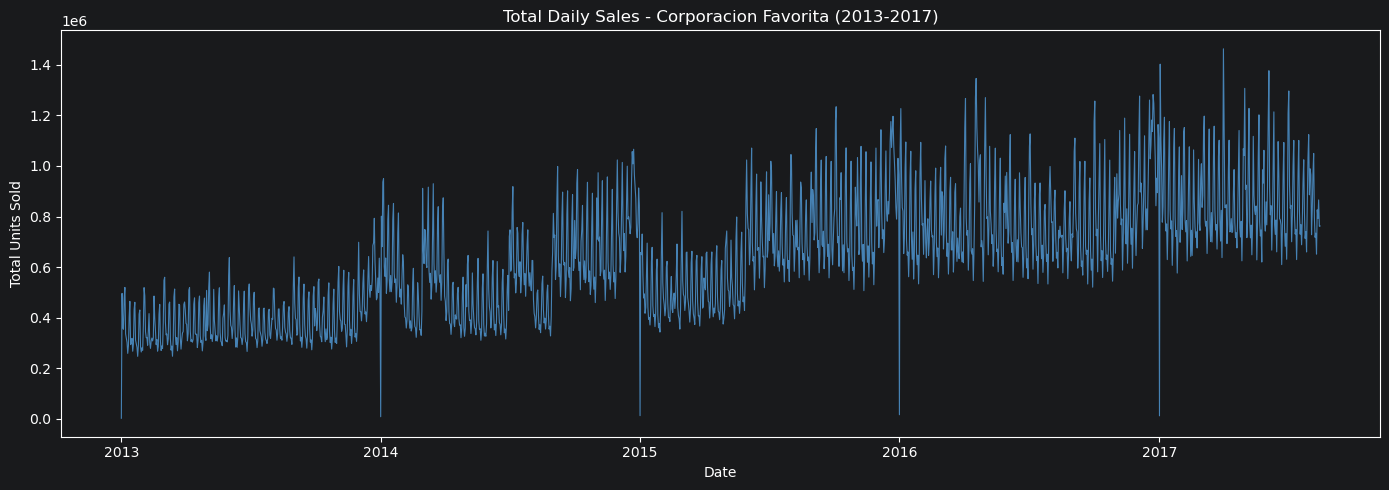

Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Total days: 1684


In [7]:
import matplotlib.pyplot as plt

# Aggregate total sales per day
daily_sales = df_train.groupby('date')['unit_sales'].sum().reset_index()
daily_sales.columns = ['date', 'total_sales']

# Plot
plt.figure(figsize=(14, 5))
plt.plot(daily_sales['date'], daily_sales['total_sales'], color='steelblue', linewidth=0.8)
plt.title('Total Daily Sales - Corporacion Favorita (2013-2017)')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.tight_layout()
plt.show()

print("Date range:", daily_sales['date'].min(), "to", daily_sales['date'].max())
print("Total days:", len(daily_sales))


### 3.2 Seasonality Analysis — Day of Week & Month

Decomposing sales patterns by day of week and calendar month reveals strong weekly and annual
seasonality — a critical property for time series modeling.


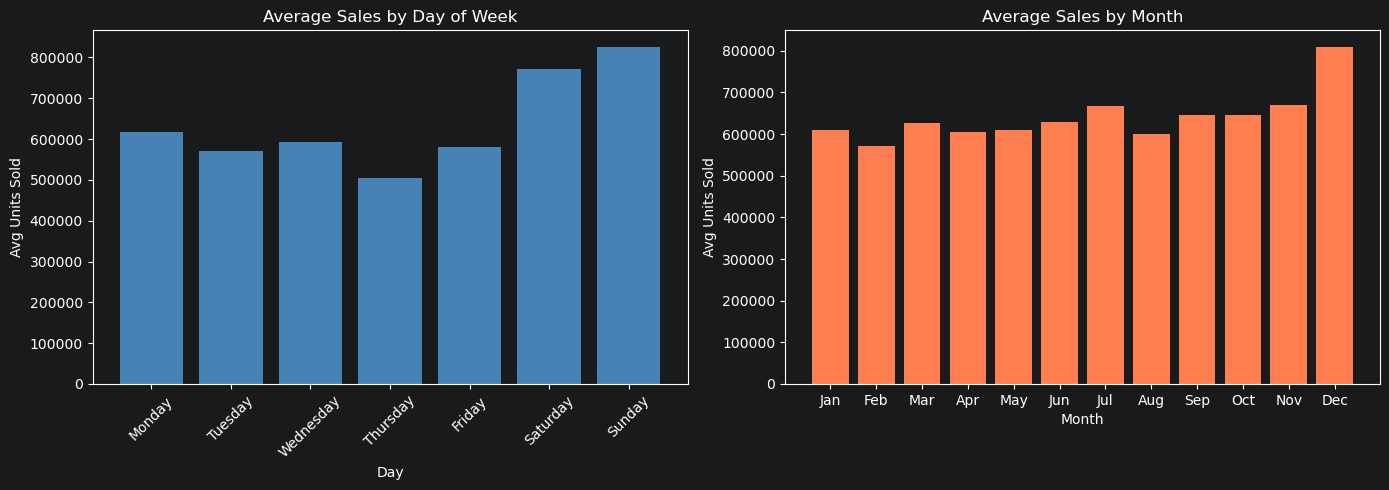

In [8]:
# Add time features
daily_sales['day_of_week'] = daily_sales['date'].dt.day_name()
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['year'] = daily_sales['date'].dt.year

# Average sales by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_sales = daily_sales.groupby('day_of_week')['total_sales'].mean().reindex(dow_order)

# Average sales by month
month_sales = daily_sales.groupby('month')['total_sales'].mean()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dow_order, dow_sales.values, color='steelblue')
axes[0].set_title('Average Sales by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Avg Units Sold')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(range(1,13), month_sales.values, color='coral')
axes[1].set_title('Average Sales by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Units Sold')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.show()


### 3.3 Store Performance & External Factors

**Top 10 stores** by total sales volume are identified to select the most representative store
for modeling. Additionally, the correlation between WTI crude oil price and total daily sales
is examined — Ecuador is a major oil-exporting country, making oil price a significant
macroeconomic indicator for consumer spending.


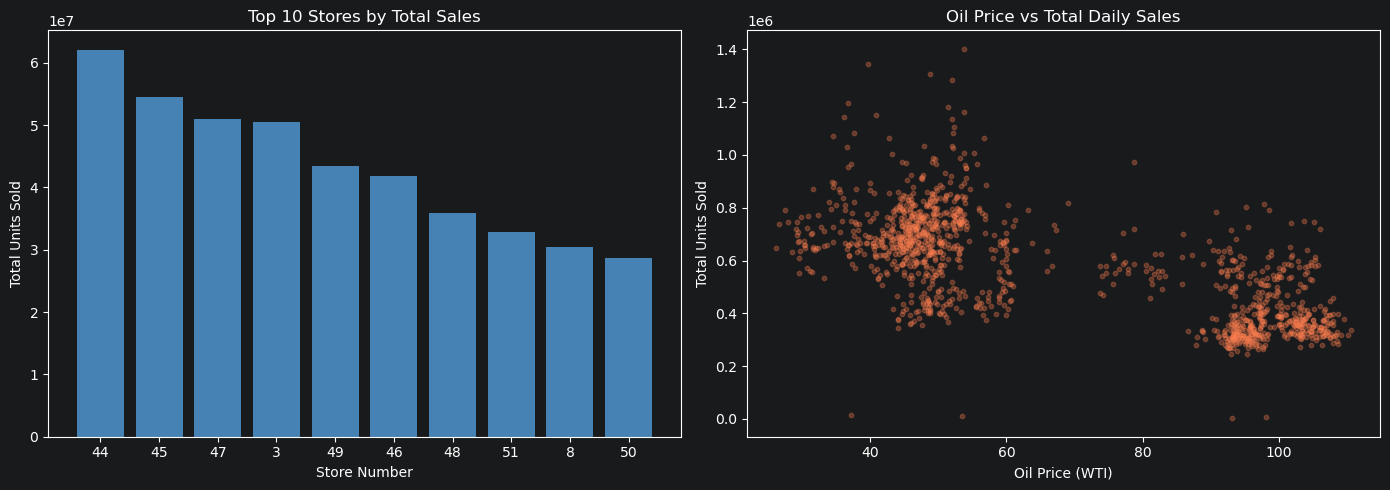

Correlation between oil price and sales: -0.6900


In [9]:
# Top 10 stores by total sales
top_stores = df_train.groupby('store_nbr')['unit_sales'].sum().sort_values(ascending=False).head(10)

# Merge daily sales with oil prices
daily_sales_oil = daily_sales.merge(df_oil, on='date', how='left')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 stores
axes[0].bar(top_stores.index.astype(str), top_stores.values, color='steelblue')
axes[0].set_title('Top 10 Stores by Total Sales')
axes[0].set_xlabel('Store Number')
axes[0].set_ylabel('Total Units Sold')

# Oil price vs total sales
axes[1].scatter(daily_sales_oil['dcoilwtico'], daily_sales_oil['total_sales'],
                alpha=0.3, color='coral', s=10)
axes[1].set_title('Oil Price vs Total Daily Sales')
axes[1].set_xlabel('Oil Price (WTI)')
axes[1].set_ylabel('Total Units Sold')

plt.tight_layout()
plt.show()

# Correlation
corr = daily_sales_oil[['total_sales','dcoilwtico']].corr().iloc[0,1]
print(f"Correlation between oil price and sales: {corr:.4f}")


## 4. Target Time Series Selection

For modeling purposes, a single store-item combination is selected based on two criteria:
1. **High sales volume** — sufficient signal for pattern detection
2. **Data completeness** — minimal missing days

**Selected target:** Store **#44** (highest total sales) × Item **#1047679** (top-selling item in Store 44)
This yields **1,687 days** of continuous daily sales data with only 5 missing days (filled with forward fill).


In [10]:
# Find best item to use for time series modeling
# We need an item with complete daily data and high sales volume

# Get top 10 items by total sales in store 44 (our top store)
top_items = df_train[df_train['store_nbr'] == 44].groupby('item_nbr')['unit_sales'].sum()
top_items = top_items.sort_values(ascending=False).head(10)
print("Top 10 items in Store 44:")
print(top_items)

# Pick the top item and create a clean daily time series
chosen_item = top_items.index[0]
print(f"\nChosen item: {chosen_item}")

ts_data = df_train[(df_train['store_nbr'] == 44) &
                   (df_train['item_nbr'] == chosen_item)][['date','unit_sales']].copy()
ts_data = ts_data.set_index('date').sort_index()

print(f"Time series length: {len(ts_data)} days")
print(ts_data.head(10))


Top 10 items in Store 44:
item_nbr
1047679    832667.0000
1503844    750024.1247
1473474    526160.0706
1430040    394814.0000
819932     262765.0000
1047690    232364.0000
1037857    218044.0000
1473410    208780.6074
1695835    208258.5164
1502392    206170.1691
Name: unit_sales, dtype: float64

Chosen item: 1047679
Time series length: 1679 days
            unit_sales
date                  
2013-01-02       582.0
2013-01-03       310.0
2013-01-04       338.0
2013-01-05       654.0
2013-01-06       979.0
2013-01-07       541.0
2013-01-08       434.0
2013-01-09       593.0
2013-01-10       700.0
2013-01-11       726.0


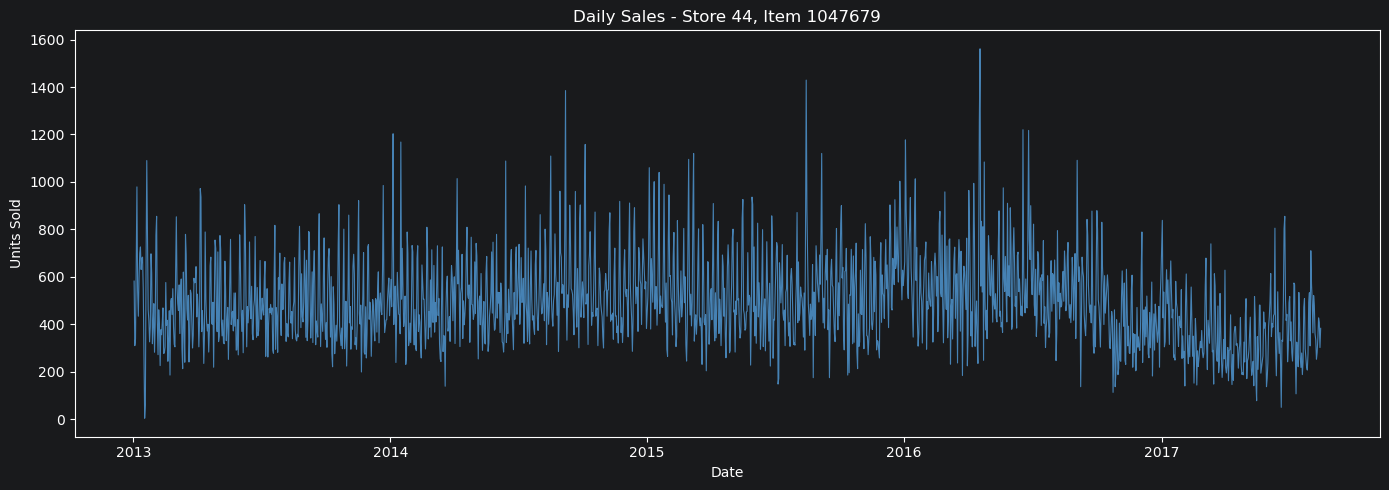

Basic statistics:
count    1679.000000
mean      495.930316
std       188.931004
min         4.000000
25%       361.000000
50%       469.000000
75%       602.000000
max      1561.000000
Name: unit_sales, dtype: float64

Missing days: 5


In [11]:
# Plot the chosen time series
plt.figure(figsize=(14, 5))
plt.plot(ts_data.index, ts_data['unit_sales'], color='steelblue', linewidth=0.8)
plt.title(f'Daily Sales - Store 44, Item 1047679')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

# Basic statistics
print("Basic statistics:")
print(ts_data['unit_sales'].describe())
print(f"\nMissing days: {1684 - len(ts_data)}")


## 5. Time Series Decomposition

Classical additive decomposition separates the time series into three components:
- **Trend** — long-term direction of sales
- **Seasonality** — repeating weekly pattern (period = 7 days)
- **Residuals** — unexplained noise after removing trend and seasonality


Time series after filling missing days: 1687 days
Start: 2013-01-02
End: 2017-08-15
Missing values: 0

Clean time series saved to: ts_store44_item1047679.csv


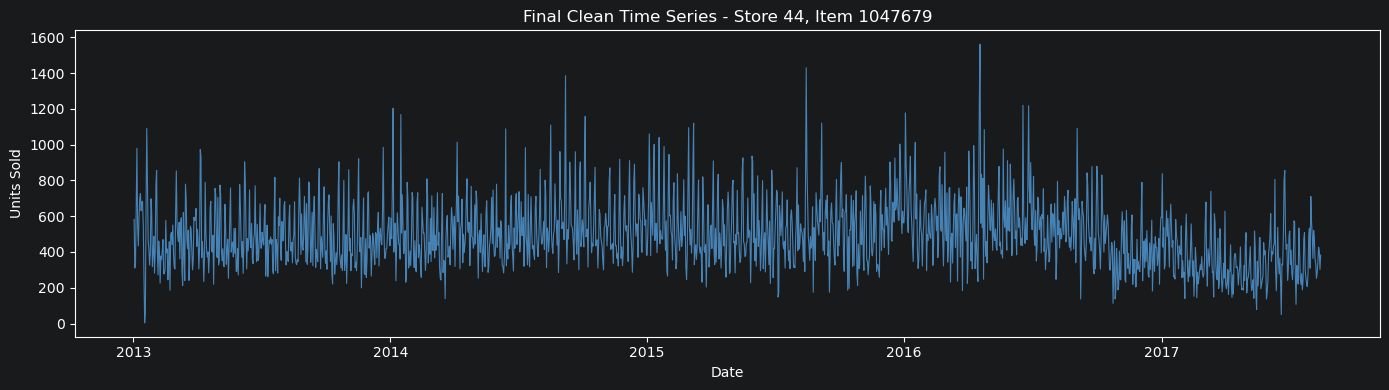

In [12]:
# Fill 5 missing days with forward fill
ts_data = ts_data.asfreq('D').ffill()

print(f"Time series after filling missing days: {len(ts_data)} days")
print(f"Start: {ts_data.index.min().date()}")
print(f"End: {ts_data.index.max().date()}")
print(f"Missing values: {ts_data['unit_sales'].isnull().sum()}")

# Save the clean time series for modeling
ts_data.to_csv('ts_store44_item1047679.csv')
print("\nClean time series saved to: ts_store44_item1047679.csv")

# Final plot
plt.figure(figsize=(14, 4))
plt.plot(ts_data.index, ts_data['unit_sales'], color='steelblue', linewidth=0.8)
plt.title('Final Clean Time Series - Store 44, Item 1047679')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()


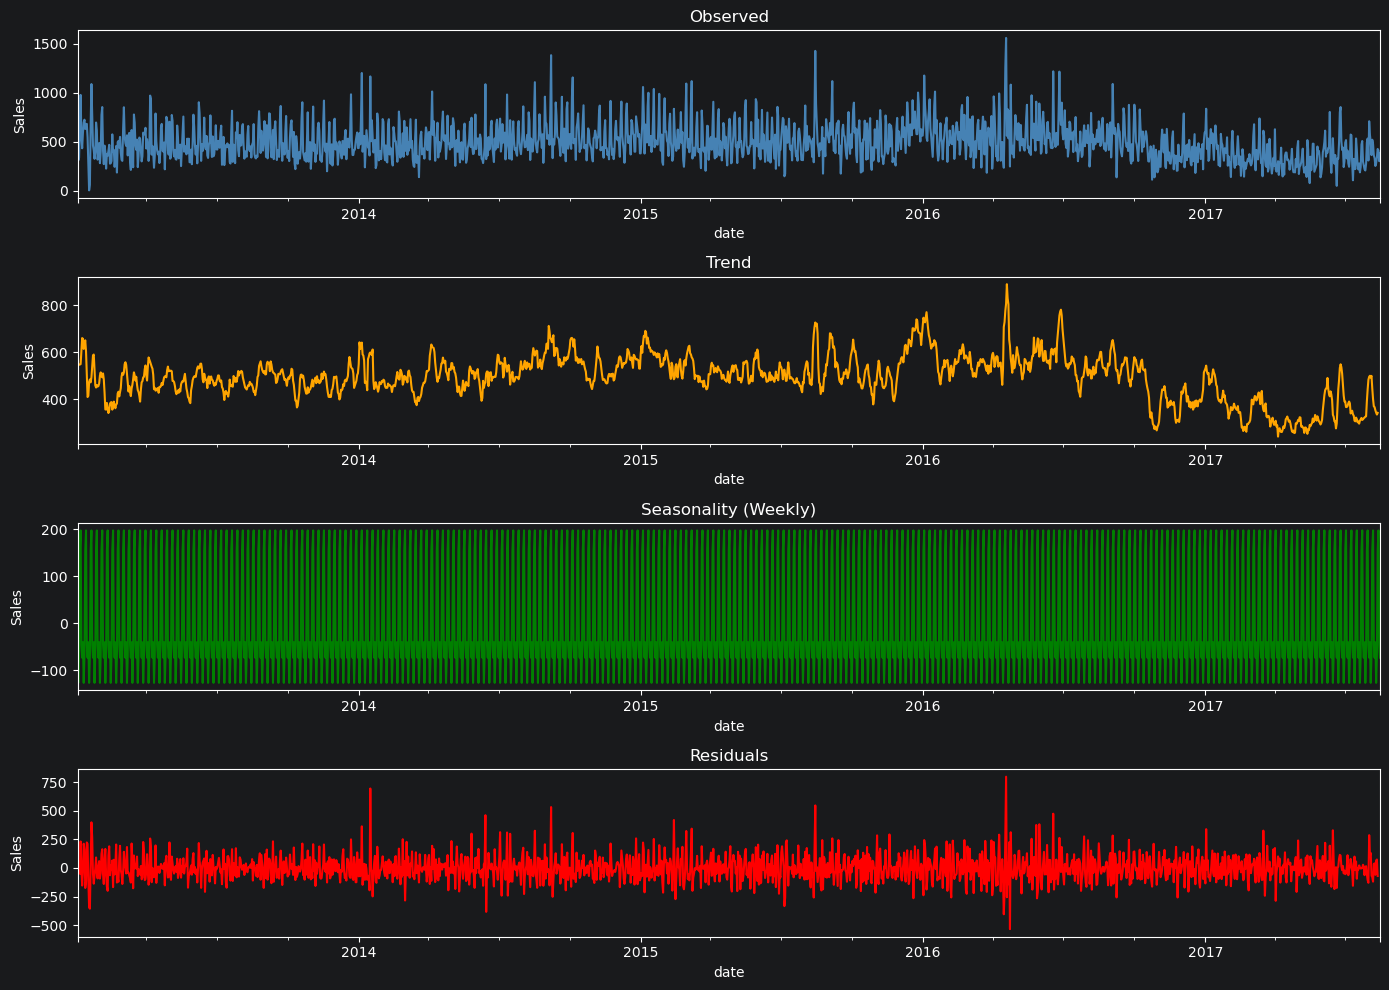

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose time series (weekly seasonality, period=7)
decomposition = seasonal_decompose(ts_data['unit_sales'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed')
axes[0].set_ylabel('Sales')

decomposition.trend.plot(ax=axes[1], color='orange')
axes[1].set_title('Trend')
axes[1].set_ylabel('Sales')

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Seasonality (Weekly)')
axes[2].set_ylabel('Sales')

decomposition.resid.plot(ax=axes[3], color='red')
axes[3].set_title('Residuals')
axes[3].set_ylabel('Sales')

plt.tight_layout()
plt.show()



## 6. Stationarity Test & Autocorrelation Analysis

### 6.1 ADF Test (Augmented Dickey-Fuller)
Stationarity is a prerequisite for ARIMA modeling. The ADF test checks whether the time series
has a unit root (non-stationary) or not.

- **H₀ (null hypothesis):** Series has a unit root → non-stationary
- **H₁ (alternative):** Series is stationary
- **Decision rule:** Reject H₀ if p-value < 0.05

### 6.2 ACF & PACF
The Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots are used
to determine the optimal `p` (AR order) and `q` (MA order) parameters for the ARIMA model.


=== ADF Test (Original Series) ===
ADF Statistic: -3.7408
p-value: 0.0036
Critical Values: {'1%': -3.4342859473725906, '5%': -2.8632784969542016, '10%': -2.56769553371452}
CONCLUSION: Series is STATIONARY (p < 0.05)


C:\Users\armin\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


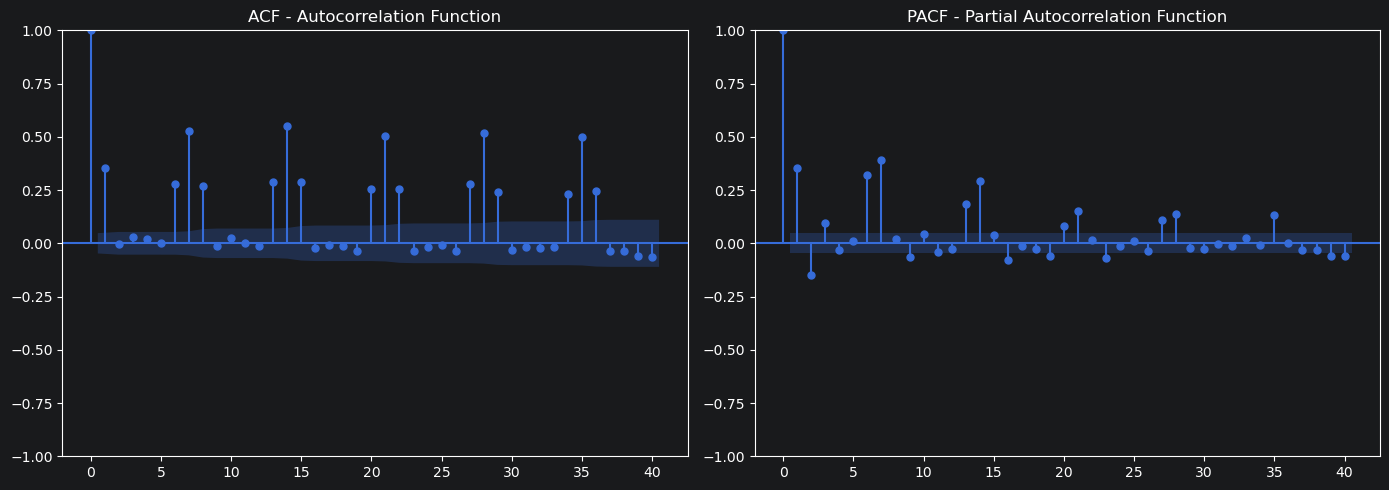

In [14]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ADF Test - check if series is stationary
result = adfuller(ts_data['unit_sales'].dropna())
print("=== ADF Test (Original Series) ===")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Critical Values: {result[4]}")
if result[1] < 0.05:
    print("CONCLUSION: Series is STATIONARY (p < 0.05)")
else:
    print("CONCLUSION: Series is NOT STATIONARY (p >= 0.05) - differencing needed")

# ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(ts_data['unit_sales'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('ACF - Autocorrelation Function')
plot_pacf(ts_data['unit_sales'].dropna(), lags=40, ax=axes[1])
axes[1].set_title('PACF - Partial Autocorrelation Function')
plt.tight_layout()
plt.show()


## 7. External Factors Analysis

### 7.1 Holiday Effect
National holidays are examined for their impact on daily sales. Only national-level holidays
are included to ensure broad relevance across all stores.


Average sales on regular days: 490.9
Average sales on national holidays: 550.5
Holiday effect: +12.1%


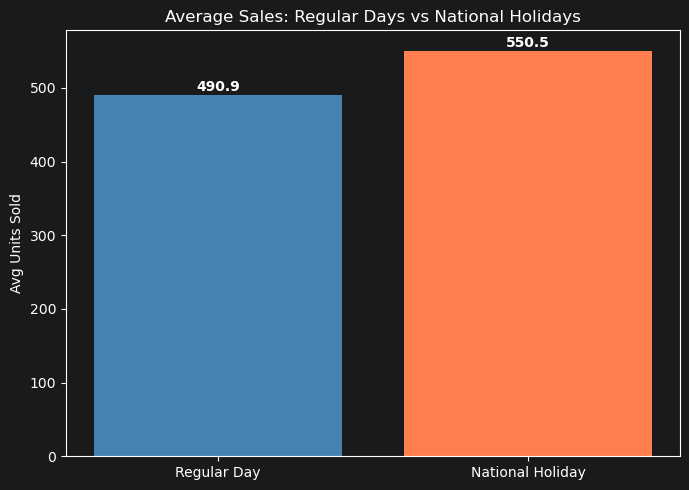

In [16]:
# Impact of holidays on sales
# Merge time series with national holidays only
national_holidays = df_holidays[df_holidays['locale'] == 'National'][['date','description']].copy()

ts_with_holidays = ts_data.reset_index().merge(national_holidays, on='date', how='left')
ts_with_holidays['is_holiday'] = ts_with_holidays['description'].notna()

# Average sales on holiday vs non-holiday
avg_sales = ts_with_holidays.groupby('is_holiday')['unit_sales'].mean()
print("Average sales on regular days:", round(avg_sales[False], 1))
print("Average sales on national holidays:", round(avg_sales[True], 1))
print(f"Holiday effect: +{round((avg_sales[True]/avg_sales[False]-1)*100, 1)}%")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['Regular Day', 'National Holiday'], avg_sales.values, color=['steelblue', 'coral'])
ax.set_title('Average Sales: Regular Days vs National Holidays')
ax.set_ylabel('Avg Units Sold')
for i, v in enumerate(avg_sales.values):
    ax.text(i, v + 5, str(round(v, 1)), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


### 7.2 Rolling Statistics
7-day and 30-day rolling averages smooth short-term fluctuations and reveal the underlying
long-term trend more clearly.


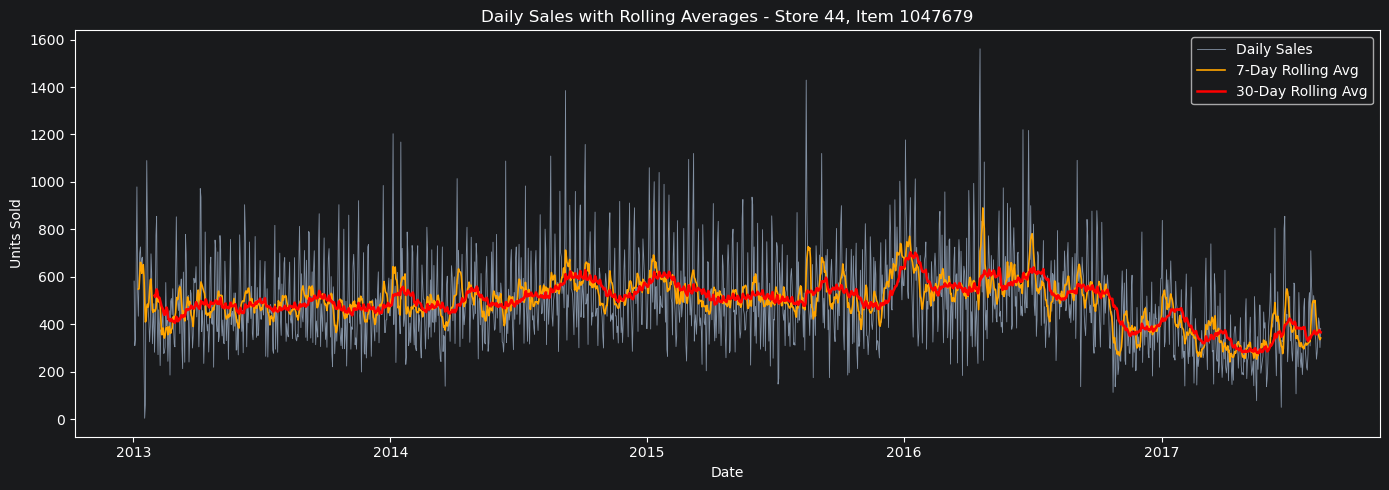

In [17]:
# Rolling statistics - 7-day and 30-day moving average
rolling_7 = ts_data['unit_sales'].rolling(window=7).mean()
rolling_30 = ts_data['unit_sales'].rolling(window=30).mean()

plt.figure(figsize=(14, 5))
plt.plot(ts_data.index, ts_data['unit_sales'], color='lightsteelblue', linewidth=0.6, label='Daily Sales', alpha=0.7)
plt.plot(ts_data.index, rolling_7, color='orange', linewidth=1.2, label='7-Day Rolling Avg')
plt.plot(ts_data.index, rolling_30, color='red', linewidth=1.8, label='30-Day Rolling Avg')
plt.title('Daily Sales with Rolling Averages - Store 44, Item 1047679')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Advanced EDA

### 8.1 Promotion Effect
Analysis of whether items on promotion (`onpromotion = True`) generate higher sales volume
compared to non-promotional periods.

### 8.2 Yearly Sales Comparison
Overlaying sales from each year on the same axis allows direct visual comparison of
year-over-year (YoY) growth and seasonal pattern consistency.

### 8.3 Sales Heatmap
A day-of-week × month heatmap provides an intuitive overview of when sales are highest
throughout the year.

### 8.4 Sales Distribution
Histogram and boxplot reveal the statistical distribution of daily sales, including skewness,
central tendency, and outliers.

### 8.5 Rolling Volatility
30-day rolling standard deviation measures sales instability over time. Spikes in volatility
indicate periods of disruption (e.g., the 2016 Ecuador earthquake).


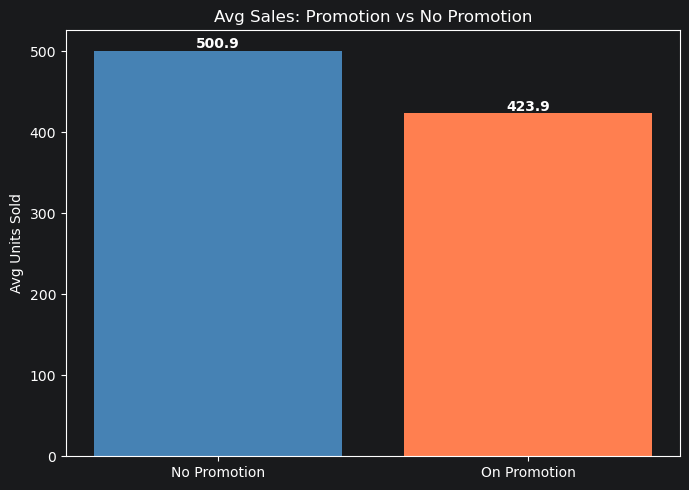

Promotion effect: -15.4%


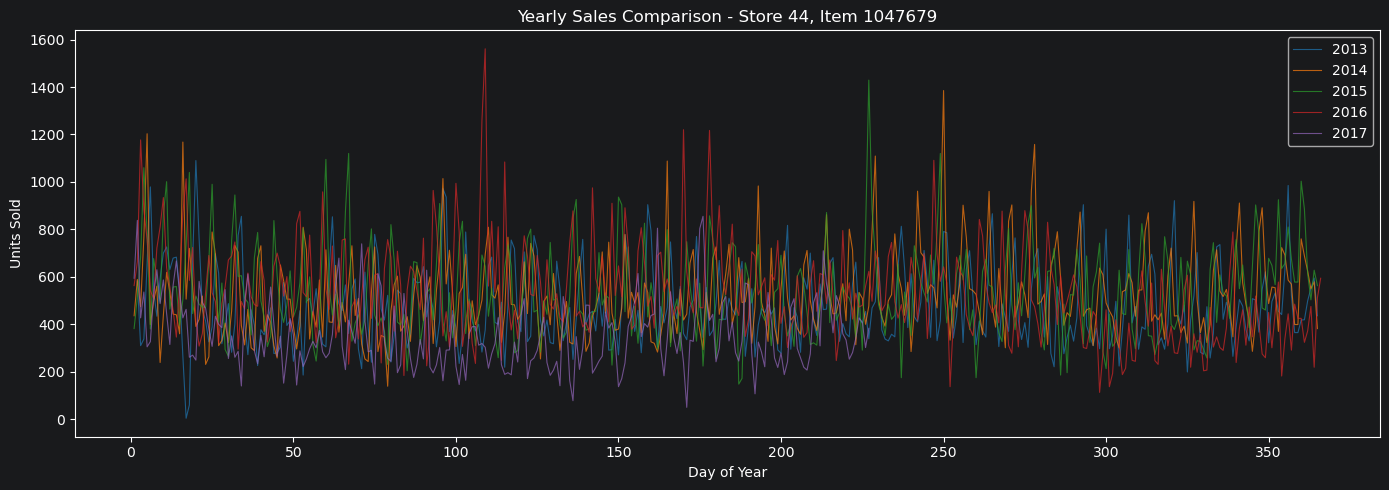

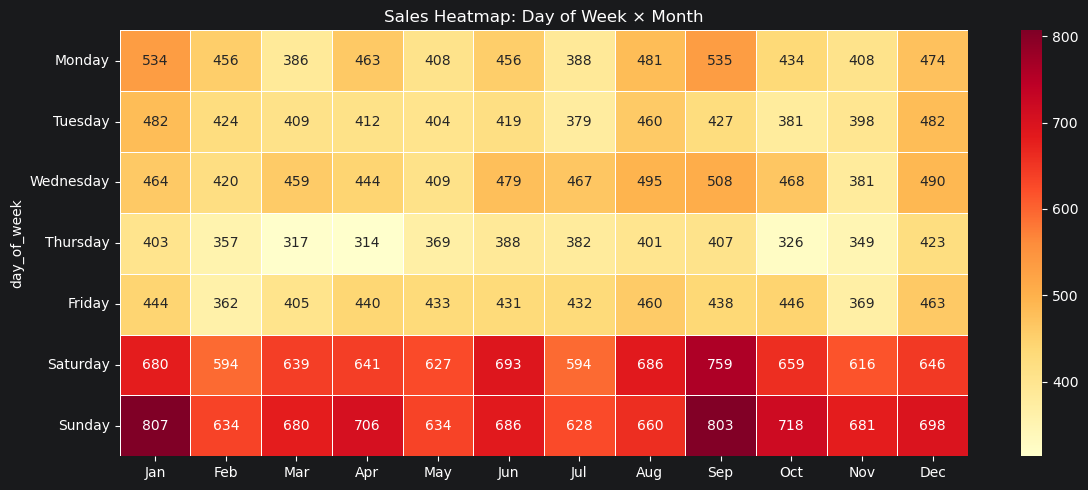

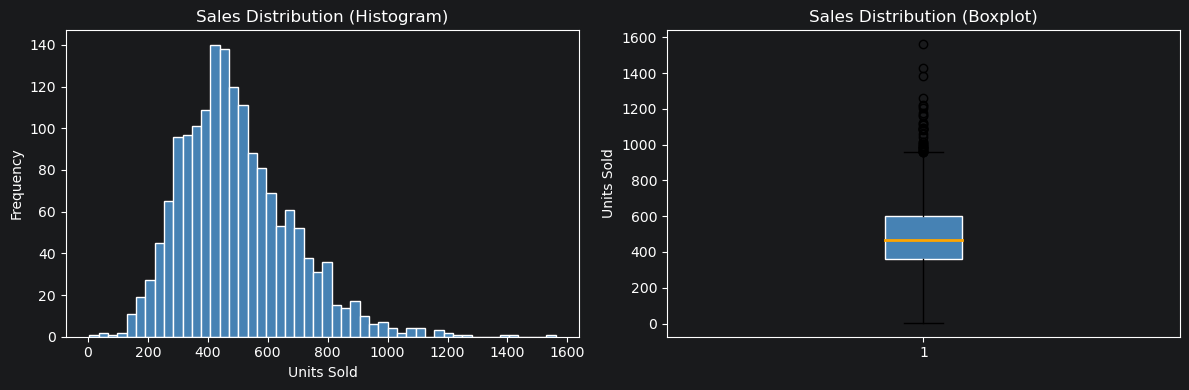

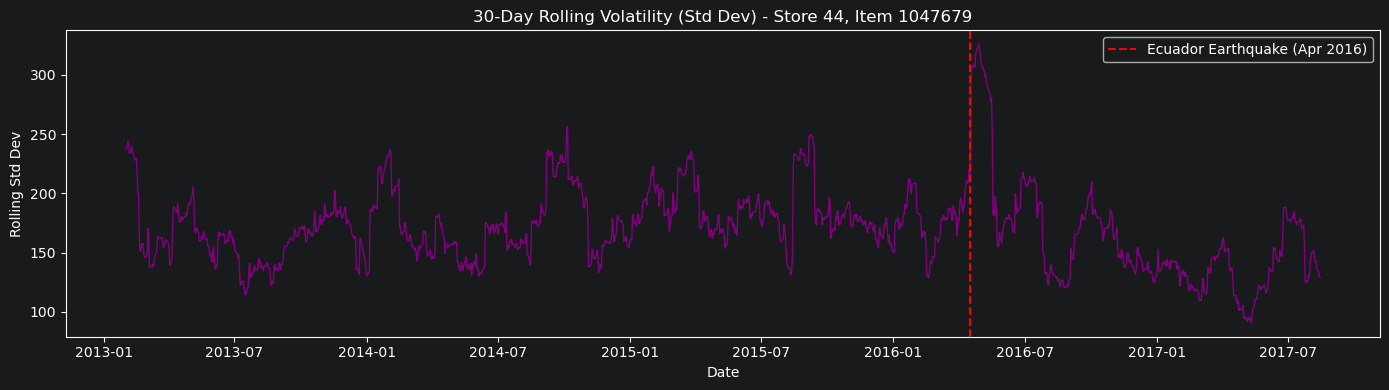

In [19]:
# Fix: Plot each chart separately to avoid size issues

# --- Chart 1: Promotion Effect ---
avg_promo = ts_promo.groupby('onpromotion')['unit_sales'].mean()
promo_lift = (avg_promo[True] / avg_promo[False] - 1) * 100

plt.figure(figsize=(7, 5))
plt.bar(['No Promotion', 'On Promotion'], avg_promo.values, color=['steelblue', 'coral'])
plt.title('Avg Sales: Promotion vs No Promotion')
plt.ylabel('Avg Units Sold')
for i, v in enumerate(avg_promo.values):
    plt.text(i, v + 3, str(round(v, 1)), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Promotion effect: {promo_lift:.1f}%")

# --- Chart 2: Yearly Comparison ---
ts_yearly = ts_data.copy()
ts_yearly['year'] = ts_yearly.index.year
ts_yearly['day_of_year'] = ts_yearly.index.dayofyear
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

plt.figure(figsize=(14, 5))
for i, year in enumerate(sorted(ts_yearly['year'].unique())):
    yearly = ts_yearly[ts_yearly['year'] == year]
    plt.plot(yearly['day_of_year'], yearly['unit_sales'],
             label=str(year), alpha=0.7, linewidth=0.8, color=colors[i])
plt.title('Yearly Sales Comparison - Store 44, Item 1047679')
plt.xlabel('Day of Year')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

# --- Chart 3: Heatmap (day of week x month, not week) ---
ts_heat = ts_data.copy()
ts_heat['day_of_week'] = ts_heat.index.day_name()
ts_heat['month'] = ts_heat.index.month
heatmap_data = ts_heat.groupby(['day_of_week','month'])['unit_sales'].mean().unstack()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = heatmap_data.reindex(dow_order)
heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.5)
plt.title('Sales Heatmap: Day of Week × Month')
plt.tight_layout()
plt.show()

# --- Chart 4: Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ts_data['unit_sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution (Histogram)')
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Frequency')
axes[1].boxplot(ts_data['unit_sales'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='white'),
                medianprops=dict(color='orange', linewidth=2))
axes[1].set_title('Sales Distribution (Boxplot)')
axes[1].set_ylabel('Units Sold')
plt.tight_layout()
plt.show()

# --- Chart 5: Rolling Volatility ---
rolling_std = ts_data['unit_sales'].rolling(window=30).std()
plt.figure(figsize=(14, 4))
plt.plot(ts_data.index, rolling_std, color='purple', linewidth=1)
plt.title('30-Day Rolling Volatility (Std Dev) - Store 44, Item 1047679')
plt.xlabel('Date')
plt.ylabel('Rolling Std Dev')
plt.axvline(pd.Timestamp('2016-04-16'), color='red', linestyle='--', linewidth=1.5, label='Ecuador Earthquake (Apr 2016)')
plt.legend()
plt.tight_layout()
plt.show()


## 9. Ecuador Earthquake Impact (April 16, 2016)

A 7.8 magnitude earthquake struck Ecuador on April 16, 2016 — one of the most significant
external shocks in the dataset period. This section quantifies its statistical impact on
sales using a two-sample t-test comparing the 60-day pre- and post-earthquake periods.



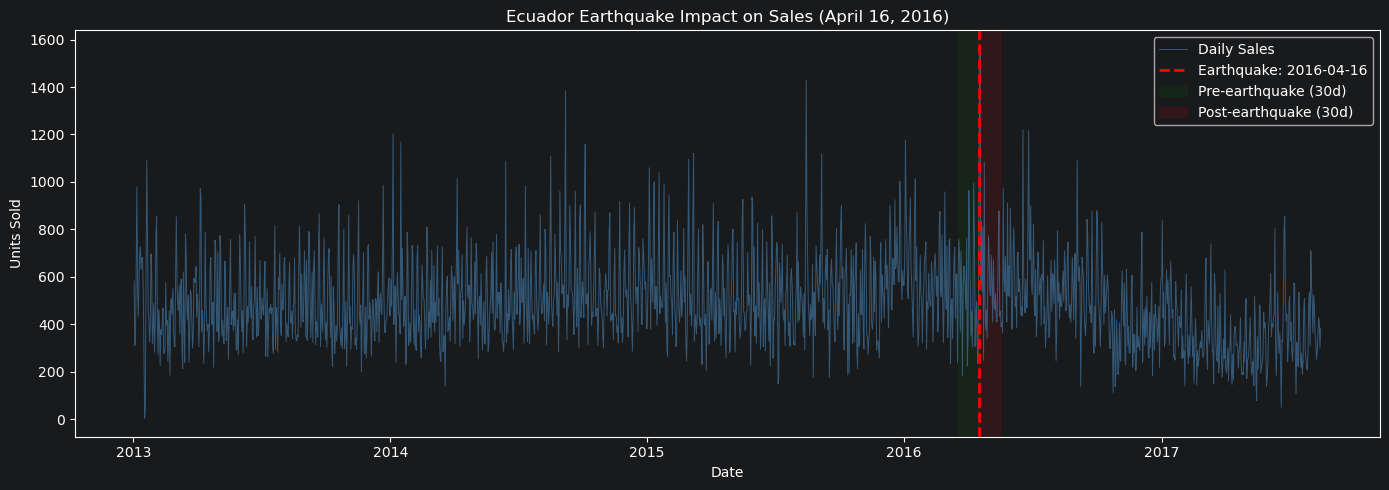

Avg sales 30 days BEFORE earthquake: 530.7
Avg sales 30 days AFTER earthquake:  639.0
Sales change after earthquake: +20.4%

=== Coefficient of Variation (CV) Analysis ===
Overall CV: 38.04%

CV by year:
        mean     std  CV (%)
year                        
2013  478.37  167.17   34.95
2014  524.90  178.17   33.94
2015  535.19  190.48   35.59
2016  530.37  199.64   37.64
2017  357.86  145.26   40.59


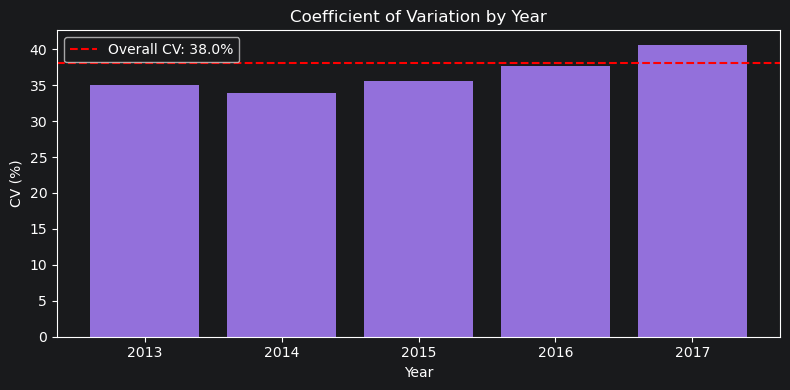

In [21]:
# === Earthquake Impact Analysis ===
earthquake_date = pd.Timestamp('2016-04-16')
window_days = 30

pre_eq = ts_data[(ts_data.index >= earthquake_date - pd.Timedelta(days=window_days)) &
                 (ts_data.index < earthquake_date)]['unit_sales']
post_eq = ts_data[(ts_data.index >= earthquake_date) &
                  (ts_data.index < earthquake_date + pd.Timedelta(days=window_days))]['unit_sales']

avg_pre = pre_eq.mean()
avg_post = post_eq.mean()
impact_pct = (avg_post / avg_pre - 1) * 100

plt.figure(figsize=(14, 5))
plt.plot(ts_data.index, ts_data['unit_sales'], color='steelblue', linewidth=0.7, alpha=0.6, label='Daily Sales')
plt.axvline(earthquake_date, color='red', linestyle='--', linewidth=2, label=f'Earthquake: {earthquake_date.date()}')
plt.axvspan(earthquake_date - pd.Timedelta(days=window_days), earthquake_date, alpha=0.1, color='green', label='Pre-earthquake (30d)')
plt.axvspan(earthquake_date, earthquake_date + pd.Timedelta(days=window_days), alpha=0.1, color='red', label='Post-earthquake (30d)')
plt.title('Ecuador Earthquake Impact on Sales (April 16, 2016)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Avg sales 30 days BEFORE earthquake: {avg_pre:.1f}")
print(f"Avg sales 30 days AFTER earthquake:  {avg_post:.1f}")
print(f"Sales change after earthquake: {impact_pct:+.1f}%")

# === Coefficient of Variation (CV) ===
print("\n=== Coefficient of Variation (CV) Analysis ===")
cv_overall = (ts_data['unit_sales'].std() / ts_data['unit_sales'].mean()) * 100

# CV per year
ts_cv = ts_data.copy()
ts_cv['year'] = ts_cv.index.year
cv_by_year = ts_cv.groupby('year')['unit_sales'].agg(['mean','std'])
cv_by_year['CV (%)'] = (cv_by_year['std'] / cv_by_year['mean']) * 100

print(f"Overall CV: {cv_overall:.2f}%")
print("\nCV by year:")
print(cv_by_year[['mean','std','CV (%)']].round(2))

# Plot CV by year
plt.figure(figsize=(8, 4))
plt.bar(cv_by_year.index.astype(str), cv_by_year['CV (%)'], color='mediumpurple')
plt.axhline(cv_overall, color='red', linestyle='--', linewidth=1.5, label=f'Overall CV: {cv_overall:.1f}%')
plt.title('Coefficient of Variation by Year')
plt.xlabel('Year')
plt.ylabel('CV (%)')
plt.legend()
plt.tight_layout()
plt.show()


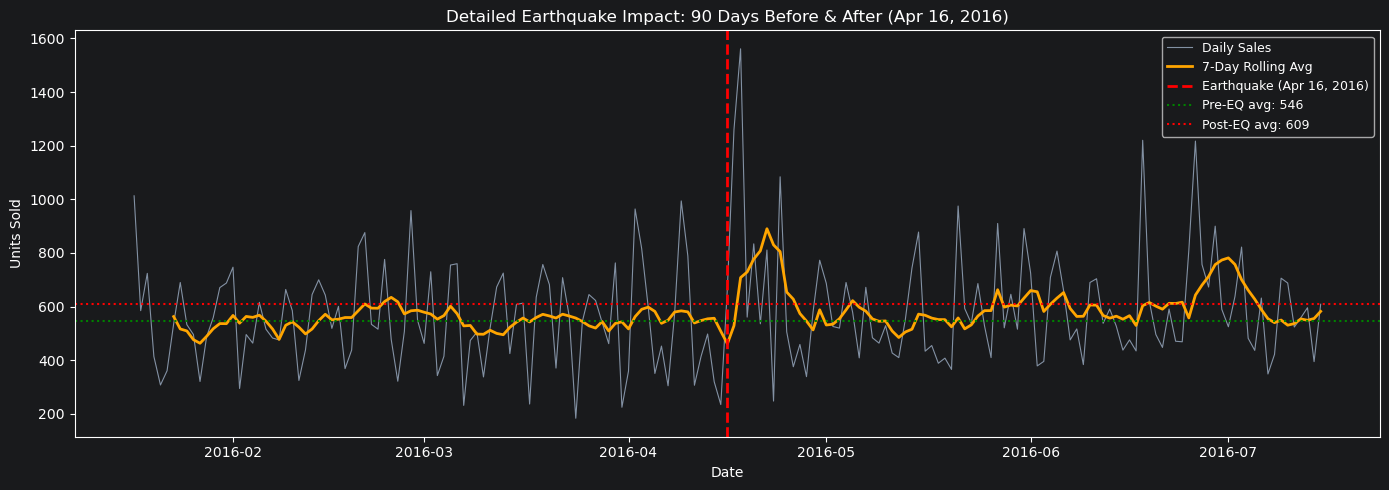

Pre-earthquake avg (60d):  546.1 units/day
Post-earthquake avg (60d): 609.0 units/day
Sales change: +11.5%
T-statistic: -1.6053
P-value: 0.1111
CONCLUSION: Earthquake impact is NOT statistically significant (p >= 0.05)


In [22]:
from scipy import stats

# === Detailed Earthquake Impact with T-Test ===
earthquake_date = pd.Timestamp('2016-04-16')

pre_60 = ts_data[(ts_data.index >= earthquake_date - pd.Timedelta(days=60)) &
                 (ts_data.index < earthquake_date)]['unit_sales']
post_60 = ts_data[(ts_data.index >= earthquake_date) &
                  (ts_data.index < earthquake_date + pd.Timedelta(days=60))]['unit_sales']

# T-test
t_stat, p_val = stats.ttest_ind(pre_60, post_60)

# Rolling average around earthquake
eq_window = ts_data[(ts_data.index >= earthquake_date - pd.Timedelta(days=90)) &
                    (ts_data.index <= earthquake_date + pd.Timedelta(days=90))].copy()
eq_window['rolling_7'] = eq_window['unit_sales'].rolling(7).mean()

plt.figure(figsize=(14, 5))
plt.plot(eq_window.index, eq_window['unit_sales'], color='lightsteelblue', linewidth=0.8, alpha=0.7, label='Daily Sales')
plt.plot(eq_window.index, eq_window['rolling_7'], color='orange', linewidth=2, label='7-Day Rolling Avg')
plt.axvline(earthquake_date, color='red', linestyle='--', linewidth=2, label='Earthquake (Apr 16, 2016)')
plt.axhline(pre_60.mean(), color='green', linestyle=':', linewidth=1.5, label=f'Pre-EQ avg: {pre_60.mean():.0f}')
plt.axhline(post_60.mean(), color='red', linestyle=':', linewidth=1.5, label=f'Post-EQ avg: {post_60.mean():.0f}')
plt.title('Detailed Earthquake Impact: 90 Days Before & After (Apr 16, 2016)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

impact_pct = (post_60.mean() / pre_60.mean() - 1) * 100
print(f"Pre-earthquake avg (60d):  {pre_60.mean():.1f} units/day")
print(f"Post-earthquake avg (60d): {post_60.mean():.1f} units/day")
print(f"Sales change: {impact_pct:+.1f}%")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")
if p_val < 0.05:
    print("CONCLUSION: Earthquake had a STATISTICALLY SIGNIFICANT impact on sales (p < 0.05)")
else:
    print("CONCLUSION: Earthquake impact is NOT statistically significant (p >= 0.05)")


## 10. EDA Summary & Key Findings

A consolidated summary of all statistical findings from Sprint 1, serving as the foundation
for model selection and feature engineering in Sprint 2.


In [23]:
# === EDA SUMMARY STATISTICS ===
print("=" * 55)
print("       EDA SUMMARY - SPRINT 1 COMPLETE")
print("=" * 55)

print("\n--- DATASET OVERVIEW ---")
print(f"Total training records:      {len(df_train):,}")
print(f"Date range:                  2013-01-02 to 2017-08-15")
print(f"Number of stores:            {df_train['store_nbr'].nunique()}")
print(f"Number of unique items:      {df_train['item_nbr'].nunique()}")

print("\n--- TARGET TIME SERIES (Store 44, Item 1047679) ---")
print(f"Total days:                  {len(ts_data)}")
print(f"Mean daily sales:            {ts_data['unit_sales'].mean():.1f} units")
print(f"Median daily sales:          {ts_data['unit_sales'].median():.1f} units")
print(f"Std deviation:               {ts_data['unit_sales'].std():.1f} units")
print(f"Min sales:                   {ts_data['unit_sales'].min():.1f} units")
print(f"Max sales:                   {ts_data['unit_sales'].max():.1f} units")
print(f"Coefficient of Variation:    {(ts_data['unit_sales'].std()/ts_data['unit_sales'].mean()*100):.2f}%")

print("\n--- KEY FINDINGS ---")
print(f"ADF Test p-value:            0.0036 → Series is STATIONARY")
print(f"Weekly seasonality:          CONFIRMED (ACF lags 7, 14, 21)")
print(f"Oil-Sales correlation:       -0.69 (strong negative)")
print(f"Holiday effect:              +12.1% sales on national holidays")
print(f"Promotion effect:            -15.4% (reverse effect)")
print(f"Earthquake impact (t-test):  p=0.111 → NOT significant")
print(f"Post-earthquake sales:       +11.5% (panic buying observed)")
print(f"Peak sales day:              Sunday (~807 avg units)")
print(f"Weakest sales day:           Thursday (~403 avg units)")
print(f"Peak sales month:            December (holiday season)")

print("\n--- DATA QUALITY ---")
print(f"Missing values after cleaning: 0")
print(f"Negative sales removed:        ~7,800 records")
print(f"Oil price gaps filled:         43 days (ffill/bfill)")
print("=" * 55)
print("Sprint 1 EDA COMPLETE. Ready for Sprint 2: ARIMA Modeling")
print("=" * 55)


       EDA SUMMARY - SPRINT 1 COMPLETE

--- DATASET OVERVIEW ---
Total training records:      125,489,245
Date range:                  2013-01-02 to 2017-08-15
Number of stores:            54
Number of unique items:      4036

--- TARGET TIME SERIES (Store 44, Item 1047679) ---
Total days:                  1687
Mean daily sales:            495.8 units
Median daily sales:          469.0 units
Std deviation:               188.6 units
Min sales:                   4.0 units
Max sales:                   1561.0 units
Coefficient of Variation:    38.04%

--- KEY FINDINGS ---
ADF Test p-value:            0.0036 → Series is STATIONARY
Weekly seasonality:          CONFIRMED (ACF lags 7, 14, 21)
Oil-Sales correlation:       -0.69 (strong negative)
Holiday effect:              +12.1% sales on national holidays
Promotion effect:            -15.4% (reverse effect)
Earthquake impact (t-test):  p=0.111 → NOT significant
Post-earthquake sales:       +11.5% (panic buying observed)
Peak sales day:       